In [ ]:
import pandas as pd
import numpy as np
import h3
import matplotlib.pyplot as plt
import geopandas as gpd
import folium

In [2]:
taxi_data_processed = pd.read_parquet(
    "../data/taxi_data_processed.parquet"
)

#final_grid = pd.read_parquet(
#    "../data/final_grid.parquet"
#)

In [3]:
taxi_data_processed.info()

<class 'pandas.DataFrame'>
Index: 6012349 entries, 0 to 6041176
Data columns (total 16 columns):
 #   Column                Dtype         
---  ------                -----         
 0   Trip ID               str           
 1   Taxi ID               str           
 2   Trip Start Timestamp  str           
 3   Trip End Timestamp    str           
 4   Trip Seconds          float64       
 5   Trip Miles            float64       
 6   Pickup Census Tract   int64         
 7   Dropoff Census Tract  int64         
 8   Trip Total            float64       
 9   Company               str           
 10  h3_index_pickup       str           
 11  h3_index_dropoff      str           
 12  h3_7_index_pickup     str           
 13  h3_9_index_pickup     str           
 14  Pickup Hour           datetime64[us]
 15  Dropoff Hour          datetime64[us]
dtypes: datetime64[us](2), float64(3), int64(2), str(9)
memory usage: 2.4 GB


## temporal patterns

In [4]:
taxi_data_processed["date"] = taxi_data_processed["Pickup Hour"].dt.date

taxi_data_processed['month'] = taxi_data_processed['Pickup Hour'].dt.month

taxi_data_processed["hour"] = taxi_data_processed["Pickup Hour"].dt.hour

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

taxi_data_processed["weekday"] = pd.Categorical(
    taxi_data_processed["Pickup Hour"].dt.day_name(),
    categories=weekday_order,
    ordered=True
)

In [5]:
hourly_demand = taxi_data_processed.groupby("hour").size()

weekly_demand = taxi_data_processed.groupby("weekday").size()

hourly_duration_mean = taxi_data_processed.groupby("hour")["Trip Seconds"].mean()

hourly_demand_avg = (
    taxi_data_processed.groupby(["date", "hour"])
    .size()
    .groupby("hour")
    .mean()
)

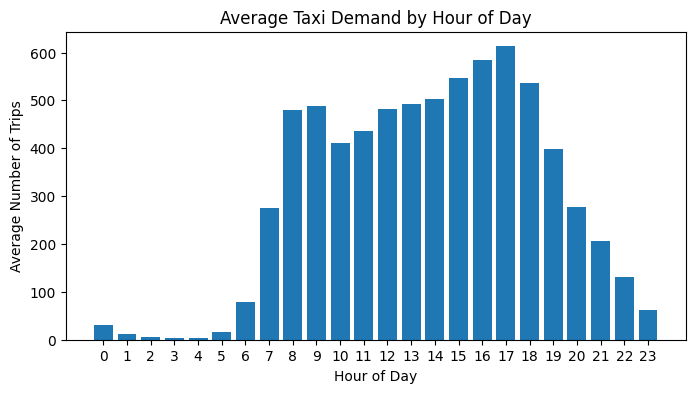

In [34]:
plt.figure(figsize=(8, 4))
plt.bar(hourly_demand_avg.index, hourly_demand_avg.values)

plt.title("Average Taxi Demand by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Number of Trips")
plt.xticks(range(24))

plt.show()

In [7]:
taxi_data_processed["is_weekend"] = (
    taxi_data_processed["Pickup Hour"].dt.dayofweek >= 5
)

hourly_weekend = (
    taxi_data_processed.groupby(["date", "hour", "is_weekend"])
    .size()
    .reset_index(name="trips")
)

hourly_weekend_avg = (
    hourly_weekend
    .groupby(["hour", "is_weekend"])["trips"]
    .mean()
    .unstack()
)

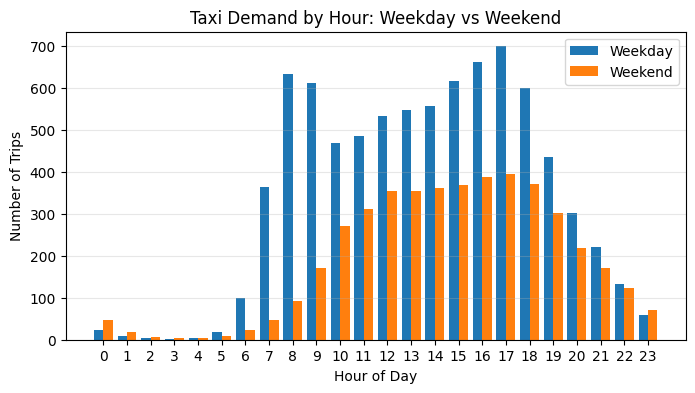

In [35]:
hours = hourly_weekend_avg.index

x = np.arange(len(hours))
width = 0.4

plt.figure(figsize=(8,4))

plt.bar(
    x - width/2,
    hourly_weekend_avg[False],
    width,
    label="Weekday"
)

plt.bar(
    x + width/2,
    hourly_weekend_avg[True],
    width,
    label="Weekend"
)

plt.xticks(x, hours)

plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.title("Taxi Demand by Hour: Weekday vs Weekend")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

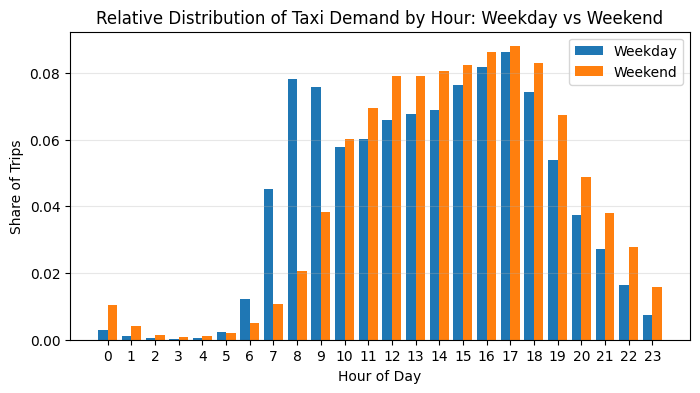

In [36]:
hourly_share = hourly_weekend_avg.div(
    hourly_weekend_avg.sum(axis=0),
    axis=1
)

x = np.arange(len(hours))
width = 0.4

plt.figure(figsize=(8,4))

plt.bar(
    x - width/2,
    hourly_share[False],
    width,
    label="Weekday"
)

plt.bar(
    x + width/2,
    hourly_share[True],
    width,
    label="Weekend"
)

plt.xticks(x, hours)

plt.xlabel("Hour of Day")
plt.ylabel("Share of Trips")
plt.title("Relative Distribution of Taxi Demand by Hour: Weekday vs Weekend")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

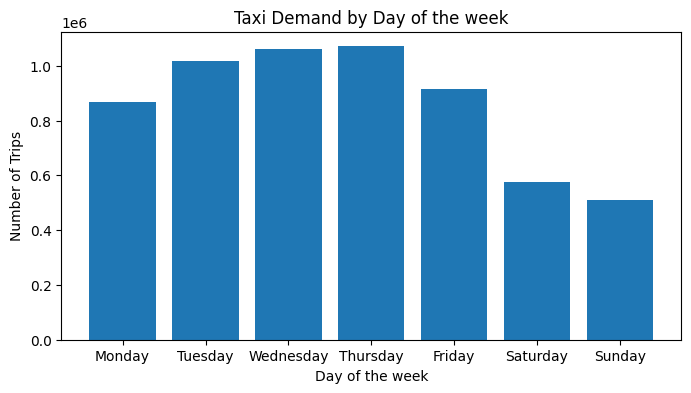

In [37]:
plt.figure(figsize=(8, 4))
plt.bar(weekly_demand.index, weekly_demand.values)

plt.title("Taxi Demand by Day of the week")
plt.xlabel("Day of the week")
plt.ylabel("Number of Trips")

plt.show()

trip length analysis

In [11]:
taxi_data_processed["Trip Miles"].describe()

count    6.012349e+06
mean     5.587106e+00
std      7.168033e+00
min      1.000000e-02
25%      9.800000e-01
50%      1.660000e+00
75%      1.064000e+01
max      4.930300e+02
Name: Trip Miles, dtype: float64

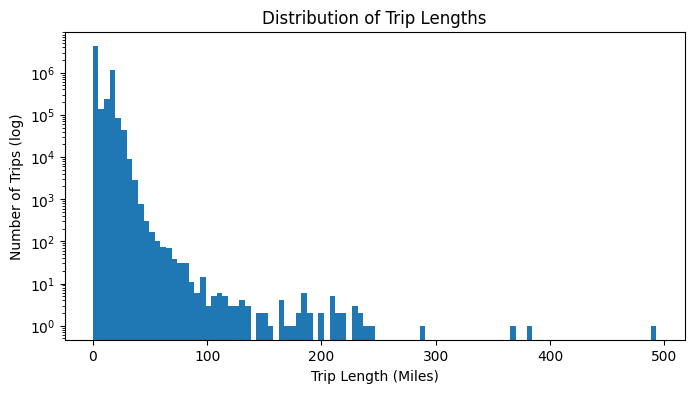

In [38]:
plt.figure(figsize=(8,4))
plt.hist(
    taxi_data_processed["Trip Miles"],
    bins=100
)
plt.xlabel("Trip Length (Miles)")
plt.ylabel("Number of Trips (log)")
plt.title("Distribution of Trip Lengths")
plt.yscale("log")
plt.show()

In [13]:
hourly_trip_length = (
    taxi_data_processed
    .groupby(
        taxi_data_processed["hour"])["Trip Miles"]
    .mean()
)

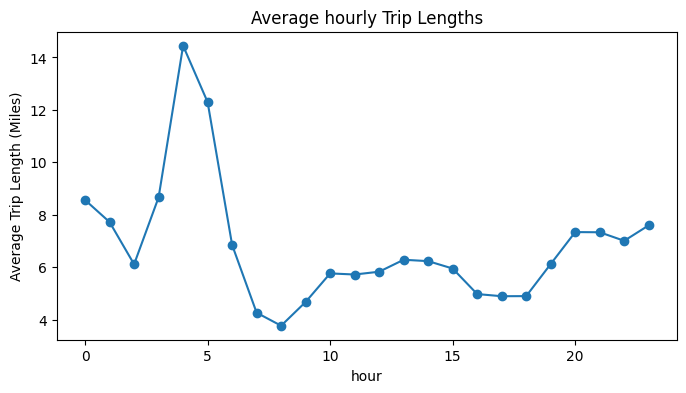

In [39]:
plt.figure(figsize=(8,4))
plt.plot(hourly_trip_length, marker = "o")
plt.xlabel("hour")
plt.ylabel("Average Trip Length (Miles)")
plt.title("Average hourly Trip Lengths")
plt.show()

price analysis

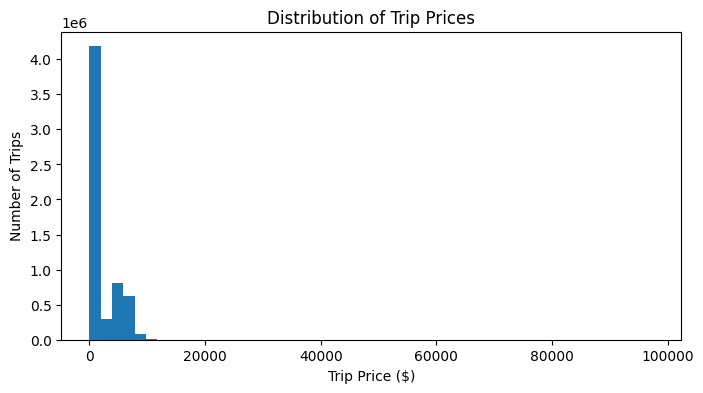

In [40]:
plt.figure(figsize=(8,4))

plt.hist(
    taxi_data_processed["Trip Total"],
    bins=50
)

plt.title("Distribution of Trip Prices")
plt.xlabel("Trip Price ($)")
plt.ylabel("Number of Trips")

plt.show()

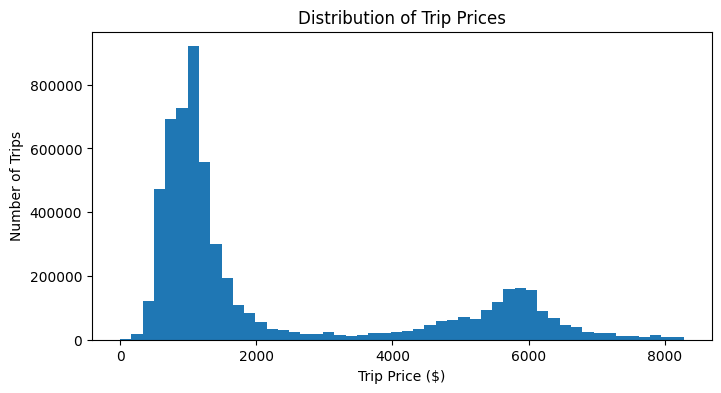

In [41]:
fare_99 = taxi_data_processed["Trip Total"].quantile(0.99)

plt.figure(figsize=(8,4))

plt.hist(
    taxi_data_processed.loc[
        taxi_data_processed["Trip Total"] <= fare_99,
        "Trip Total"
    ],
    bins=50
)

plt.title("Distribution of Trip Prices")
plt.xlabel("Trip Price ($)")
plt.ylabel("Number of Trips")

plt.show()

In [17]:
taxi_data_processed["Trip Total"].describe(
    percentiles=[0.5,0.9,0.95,0.99]
)

count    6.012349e+06
mean     2.336682e+03
std      2.212743e+03
min      0.000000e+00
50%      1.175000e+03
90%      5.950000e+03
95%      6.406000e+03
99%      8.280000e+03
max      9.750000e+04
Name: Trip Total, dtype: float64

In [18]:
hourly_avg_price = (
    taxi_data_processed
    .groupby("hour")["Trip Total"]
    .mean()
)

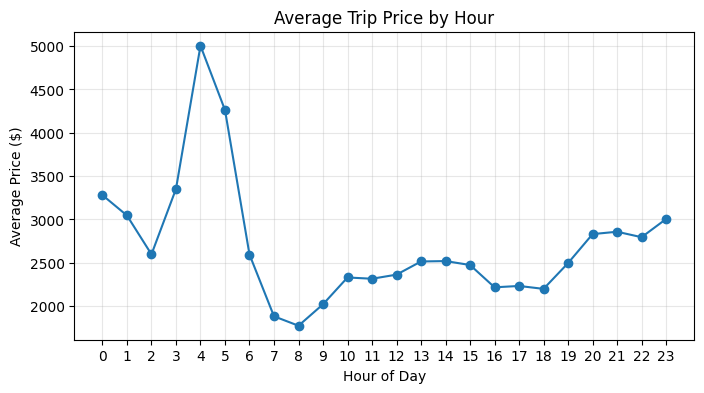

In [42]:
plt.figure(figsize=(8,4))

plt.plot(
    hourly_avg_price.index,
    hourly_avg_price.values,
    marker="o"
)

plt.title("Average Trip Price by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Price ($)")
plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.show()